# Camera calibration
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YoniChechik/AI_is_Math/blob/master/c_07_camera_calibration/multi_plane_calib.ipynb)



camera calibration for distorted images with chess board samples
reads distorted images, calculates the calibration and write undistorted images

original code is from opencv tutorials:

https://github.com/opencv/opencv/blob/master/samples/python/calibrate.py

https://opencv-python-tutroals.readthedocs.io/en/latest/py_tutorials/py_calib3d/py_pose/py_pose.html

read more about the functions here:

https://docs.opencv2.org/2.4/modules/calib3d/doc/camera_calibration_and_3d_reconstruction.html

a reference calibration plane for printing can be copied from here:

https://stackoverflow.com/questions/25233198/opencv-2-4-9-for-python-cannot-find-chessboard-camera-calibration-tutorial

Based on: https://colab.research.google.com/github/YoniChechik/AI_is_Math/blob/master/c_07_camera_calibration/multi_plane_calib.ipynb?authuser=1



In [1]:
from glob import glob

import cv2
import matplotlib.pyplot as plt
import numpy as np

#Carrega eu drive na pasta abaixo
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os
pasta = "/content/drive/MyDrive/ModelagemComputacional/RobotPerception/Atividade1/calibracao"
print(os.path.exists(pasta))
print(sorted(os.listdir(pasta)))

True
['20260930_203459.jpg', '20260930_203515.jpg', '20260930_203525.jpg', '20260930_203529.jpg', '20260930_203537.jpg', '20260930_203543.jpg', '20260930_203614.jpg', '20260930_203618.jpg', '20260930_203623.jpg', '20260930_203630.jpg', '20260930_203704.jpg', '20260930_203709.jpg', '20260930_203724.jpg', '20260930_203729.jpg', '20260930_203734.jpg', '20260930_203741.jpg', '20260930_203748.jpg', '20260930_203754.jpg', '20260930_203820.jpg', '20260930_203831.jpg']


In [3]:
#Board Size cm
square_size = 2
#Folder with the images
img_mask = "/content/drive/MyDrive/ModelagemComputacional/RobotPerception/Atividade1/calibracao/*.jpg"
#Squares in the board
pattern_size = (7, 9)
figsize = (20, 20)


In [4]:
img_names = glob(img_mask)
print(img_names)
num_images = len(img_names)
print(num_images)

pattern_points = np.zeros((np.prod(pattern_size), 3), np.float32)
pattern_points[:, :2] = np.indices(pattern_size).T.reshape(-1, 2)
pattern_points *= square_size

obj_points = []
img_points = []
h, w = cv2.imread(img_names[0]).shape[:2]


['/content/drive/MyDrive/ModelagemComputacional/RobotPerception/Atividade1/calibracao/20260930_203709.jpg', '/content/drive/MyDrive/ModelagemComputacional/RobotPerception/Atividade1/calibracao/20260930_203704.jpg', '/content/drive/MyDrive/ModelagemComputacional/RobotPerception/Atividade1/calibracao/20260930_203724.jpg', '/content/drive/MyDrive/ModelagemComputacional/RobotPerception/Atividade1/calibracao/20260930_203729.jpg', '/content/drive/MyDrive/ModelagemComputacional/RobotPerception/Atividade1/calibracao/20260930_203831.jpg', '/content/drive/MyDrive/ModelagemComputacional/RobotPerception/Atividade1/calibracao/20260930_203543.jpg', '/content/drive/MyDrive/ModelagemComputacional/RobotPerception/Atividade1/calibracao/20260930_203525.jpg', '/content/drive/MyDrive/ModelagemComputacional/RobotPerception/Atividade1/calibracao/20260930_203614.jpg', '/content/drive/MyDrive/ModelagemComputacional/RobotPerception/Atividade1/calibracao/20260930_203618.jpg', '/content/drive/MyDrive/ModelagemCom

## Step 1: find all corners in calibration plane


processing /content/drive/MyDrive/ModelagemComputacional/RobotPerception/Atividade1/calibracao/20260930_203709.jpg... 
/content/drive/MyDrive/ModelagemComputacional/RobotPerception/Atividade1/calibracao/20260930_203709.jpg... OK
processing /content/drive/MyDrive/ModelagemComputacional/RobotPerception/Atividade1/calibracao/20260930_203704.jpg... 
/content/drive/MyDrive/ModelagemComputacional/RobotPerception/Atividade1/calibracao/20260930_203704.jpg... OK
processing /content/drive/MyDrive/ModelagemComputacional/RobotPerception/Atividade1/calibracao/20260930_203724.jpg... 
/content/drive/MyDrive/ModelagemComputacional/RobotPerception/Atividade1/calibracao/20260930_203724.jpg... OK
processing /content/drive/MyDrive/ModelagemComputacional/RobotPerception/Atividade1/calibracao/20260930_203729.jpg... 
/content/drive/MyDrive/ModelagemComputacional/RobotPerception/Atividade1/calibracao/20260930_203729.jpg... OK
processing /content/drive/MyDrive/ModelagemComputacional/RobotPerception/Atividade1/

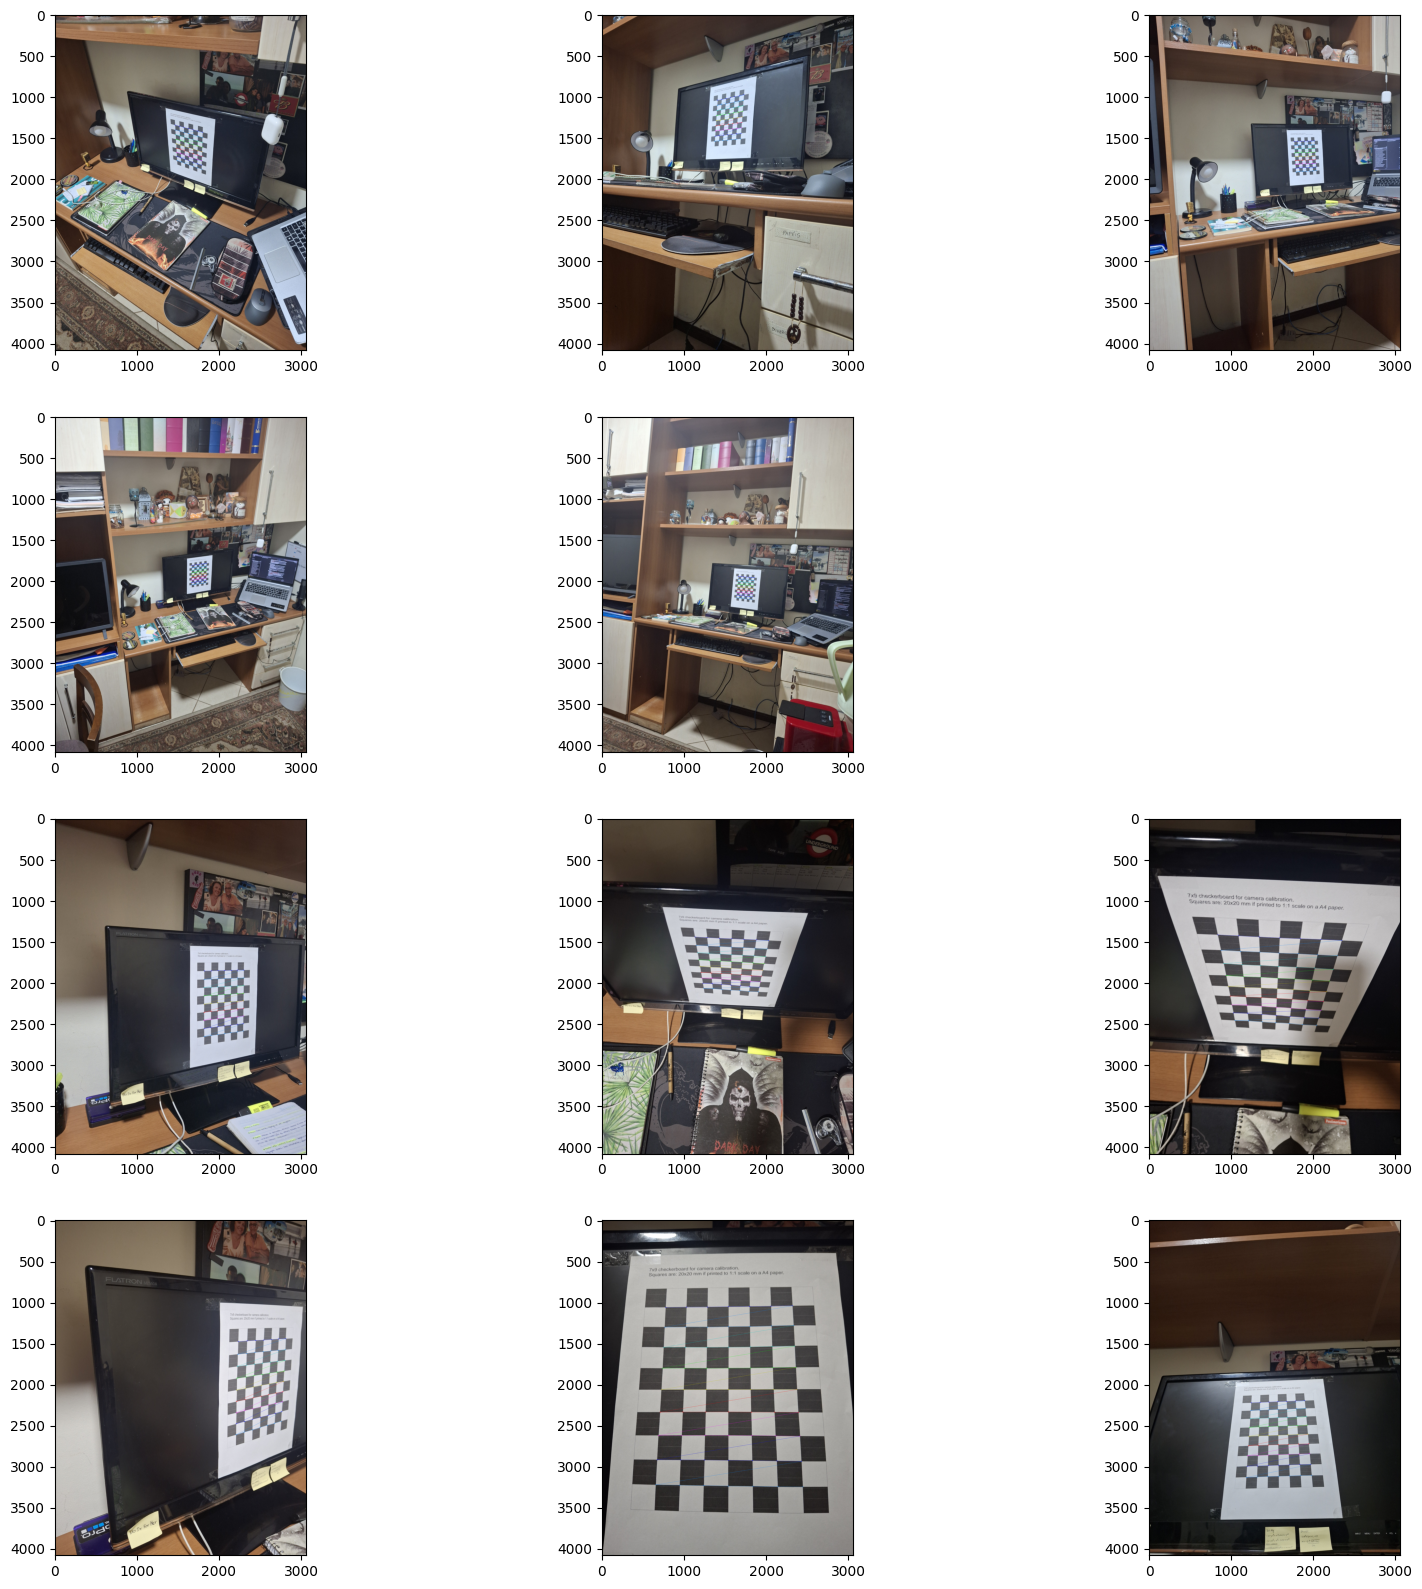

In [5]:
plt.figure(figsize=figsize)

for i, fn in enumerate(img_names):
    print("processing %s... " % fn)
    imgBGR = cv2.imread(fn)

    if imgBGR is None:
        print("Failed to load", fn)
        continue

    imgRGB = cv2.cvtColor(imgBGR, cv2.COLOR_BGR2RGB)
    img = cv2.cvtColor(imgRGB, cv2.COLOR_RGB2GRAY)

    assert w == img.shape[1] and h == img.shape[0], f"size: {img.shape[1]} x {img.shape[0]}"
    found, corners = cv2.findChessboardCorners(img, pattern_size)


    if not found:
        print("chessboard not found")
        continue

    if i < 12:
        img_w_corners = cv2.drawChessboardCorners(imgRGB, pattern_size, corners, found)
        plt.subplot(4, 3, i + 1)
        plt.imshow(img_w_corners)

    print(f"{fn}... OK")
    img_points.append(corners.reshape(-1, 2))
    obj_points.append(pattern_points)


plt.show()


## Step 2: get camera intrinsics + distortion coeffs
also get extrinsic rotation and translation vectors per image. Rotation vector is another representation for a full R matrix
more on it here: https://en.wikipedia.org/wiki/Rodrigues%27_rotation_formula


In [6]:
# calculate camera distortion
rms, camera_matrix, dist_coefs, _rvecs, _tvecs = cv2.calibrateCamera(obj_points, img_points, (w, h), None, None)

print("\nRMS:", rms)
print("camera matrix:\n", camera_matrix)
print("distortion coefficients: ", dist_coefs.ravel())



RMS: 1.2270584153179542
camera matrix:
 [[2.99267524e+03 0.00000000e+00 1.49158907e+03]
 [0.00000000e+00 3.00342427e+03 2.02820775e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
distortion coefficients:  [ 2.67356608e-01 -1.09544941e+00  9.97767733e-04  2.78830939e-04
  1.34702631e+00]


## Build undistorted images


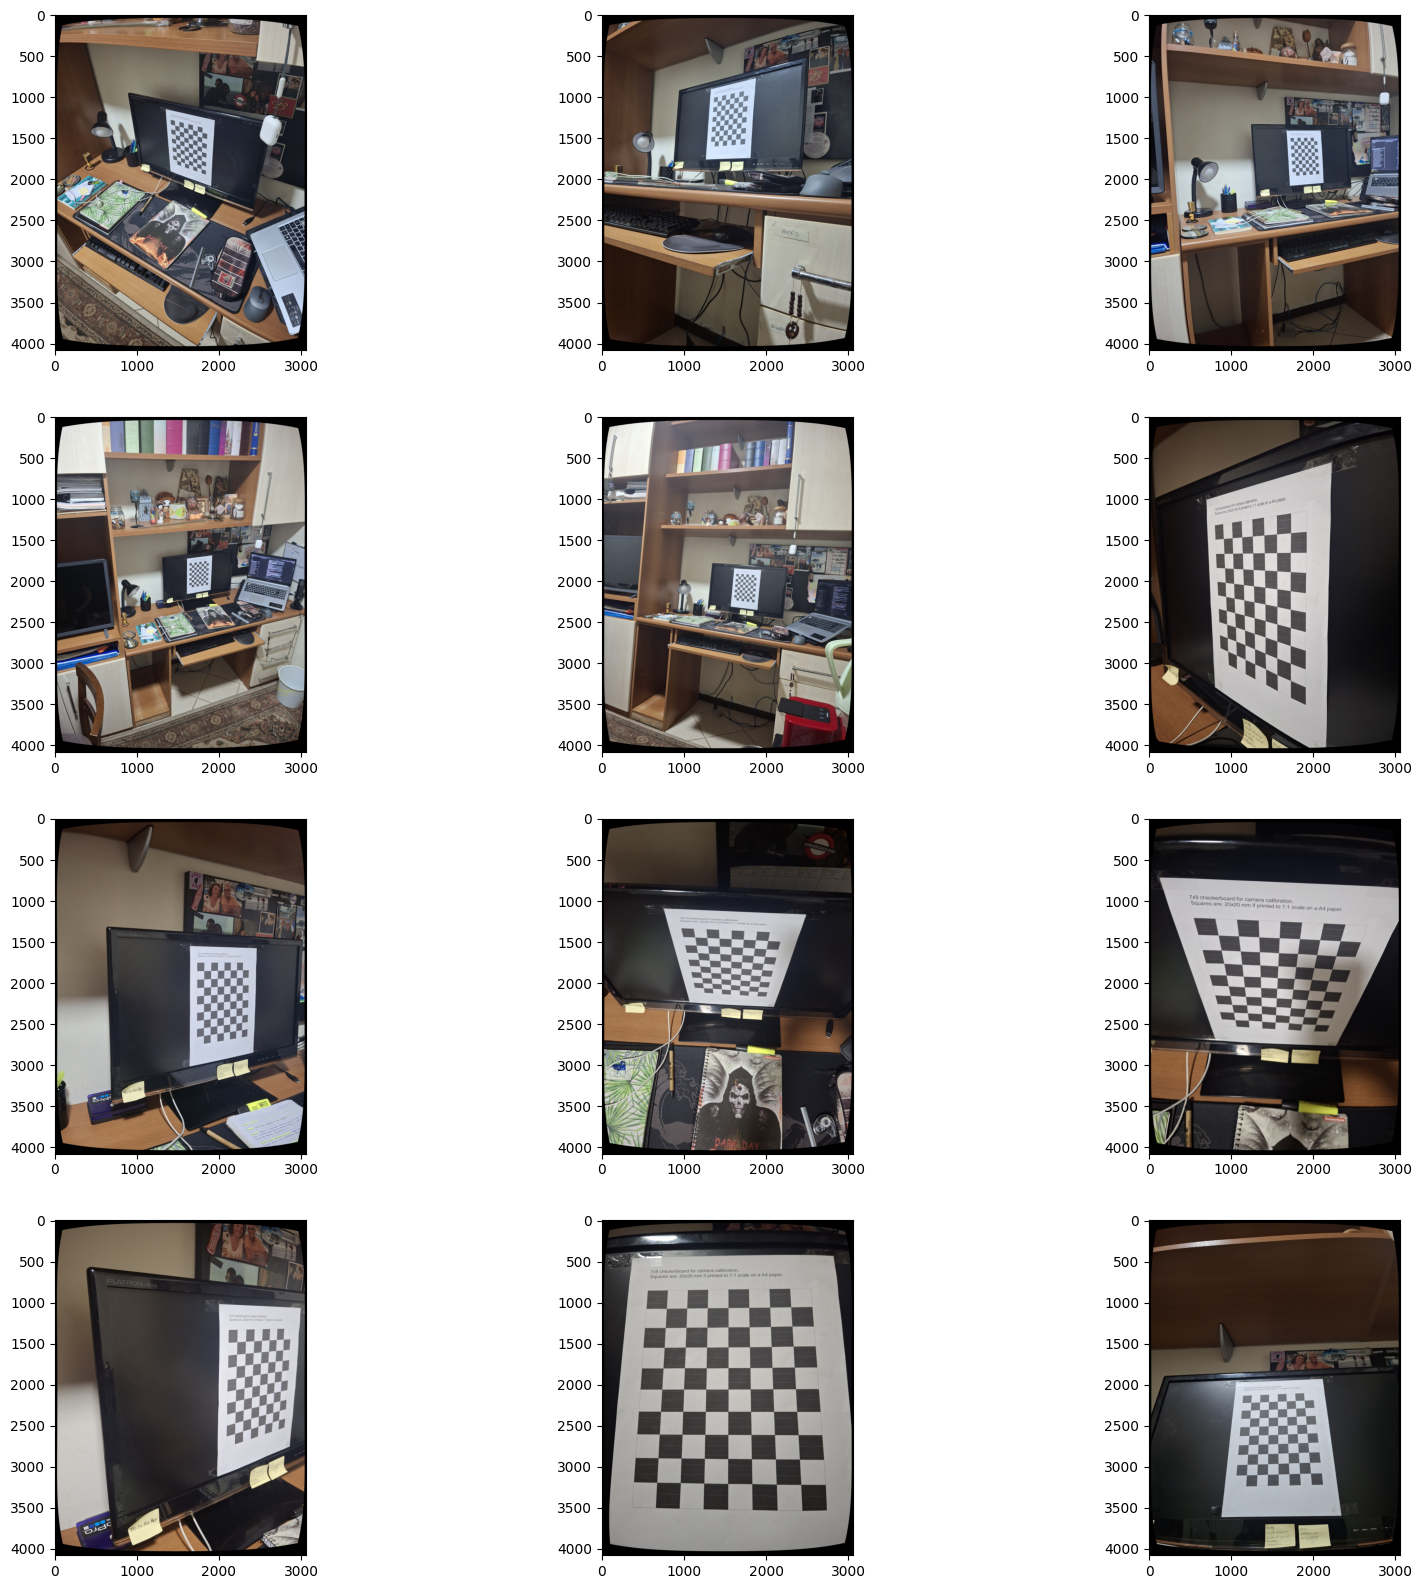

Done


In [7]:
# undistort the image with the calibration
plt.figure(figsize=figsize)
for i, fn in enumerate(img_names):
    imgBGR = cv2.imread(fn)
    imgRGB = cv2.cvtColor(imgBGR, cv2.COLOR_BGR2RGB)

    dst = cv2.undistort(imgRGB, camera_matrix, dist_coefs)

    if i < 12:
        plt.subplot(4, 3, i + 1)
        plt.imshow(dst)

plt.show()
print("Done")

Resolution: 3060 x 4080
fx = 2992.68  fy = 3003.42
cx = 1491.59  cy = 2028.21
k1, k2, p1, p2, k3 = [ 2.67356608e-01 -1.09544941e+00  9.97767733e-04  2.78830939e-04
  1.34702631e+00]
Image 0: 0.7974 px
Image 1: 1.2008 px
Image 2: 0.4924 px
Image 3: 0.5846 px
Image 4: 0.6522 px
Image 5: 1.5569 px
Image 6: 1.7268 px
Image 7: 2.6243 px
Image 8: 1.8866 px
Image 9: 1.8307 px
Image 10: 1.4711 px
Image 11: 1.0076 px
Image 12: 0.4191 px
Image 13: 0.3561 px
Image 14: 0.3988 px
Image 15: 0.3017 px
Image 16: 0.3828 px
Image 17: 0.9660 px

RMS (OpenCV): 1.2271 px
Mean reprojection error: 1.0364 px

Undistorted images saved to: /content/drive/MyDrive/ModelagemComputacional/RobotPerception/Atividade1/calibracao/undistorted


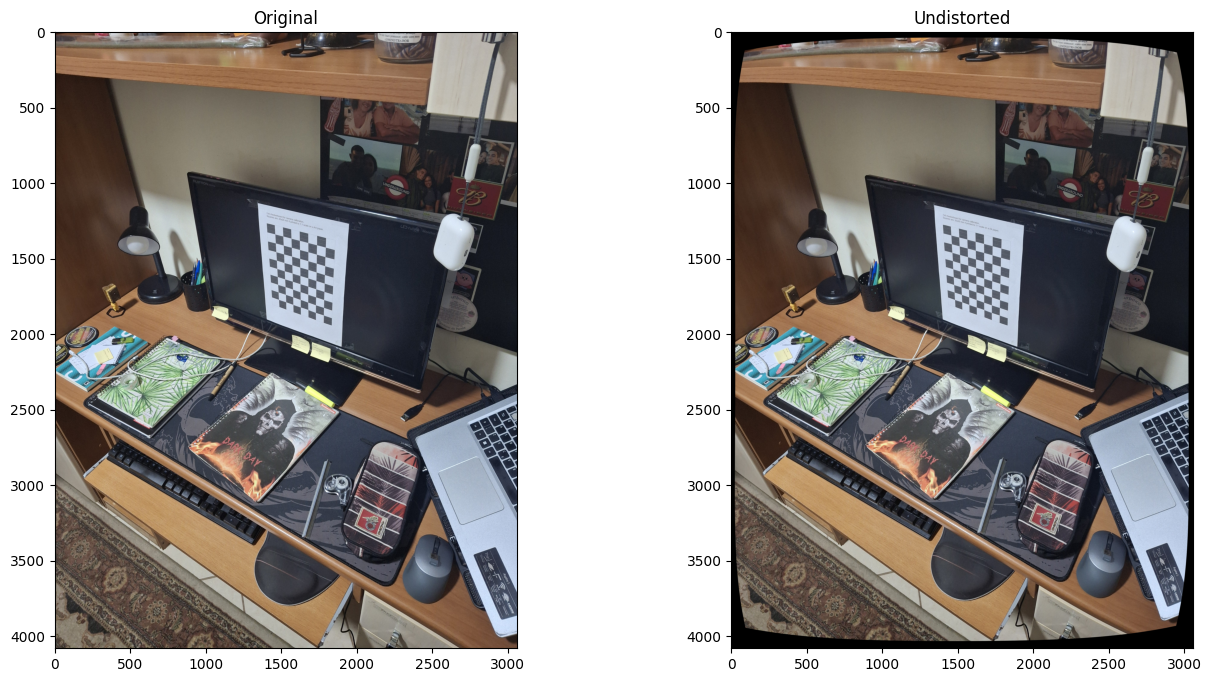

In [8]:
import os

# parameters and reprojection error
print(f"Resolution: {w} x {h}")
print(f"fx = {camera_matrix[0,0]:.2f}  fy = {camera_matrix[1,1]:.2f}")
print(f"cx = {camera_matrix[0,2]:.2f}  cy = {camera_matrix[1,2]:.2f}")
print("k1, k2, p1, p2, k3 =", dist_coefs.ravel())

errors = []
for i in range(len(obj_points)):
    proj, _ = cv2.projectPoints(obj_points[i], _rvecs[i], _tvecs[i], camera_matrix, dist_coefs)
    diff = img_points[i] - proj.reshape(-1, 2)
    errors.append(np.sqrt(np.mean(np.sum(diff**2, axis=1))))

for n, e in enumerate(errors):
    print(f"Image {n}: {e:.4f} px")
print(f"\nRMS (OpenCV): {rms:.4f} px")
print(f"Mean reprojection error: {np.mean(errors):.4f} px")

# save all undistorted images
out_dir = os.path.join(os.path.dirname(img_mask), "undistorted")
os.makedirs(out_dir, exist_ok=True)
for fn in img_names:
    img = cv2.imread(fn)
    dst = cv2.undistort(img, camera_matrix, dist_coefs)
    cv2.imwrite(os.path.join(out_dir, os.path.basename(fn)), dst)
print("\nUndistorted images saved to:", out_dir)

# before and after comparison
orig = cv2.cvtColor(cv2.imread(img_names[0]), cv2.COLOR_BGR2RGB)
dst = cv2.undistort(orig, camera_matrix, dist_coefs)
fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].imshow(orig); ax[0].set_title("Original")
ax[1].imshow(dst);  ax[1].set_title("Undistorted")
plt.savefig(os.path.join(out_dir, "comparison.png"), bbox_inches="tight")
plt.show()